# Assignment
Analyze the uploaded employee data to identify variables impacting retention, visualize the impact of salary and department on retention using bar charts, build a logistic regression model with the identified variables, and measure the model's accuracy.

In [30]:
import pandas as pd

df = pd.read_csv('data/HR_comma_sep.csv')
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## EDA

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [3]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [4]:
df.corr(numeric_only=True)['left'].sort_values(ascending=False)

left                     1.000000
time_spend_company       0.144822
average_montly_hours     0.071287
number_project           0.023787
last_evaluation          0.006567
promotion_last_5years   -0.061788
Work_accident           -0.154622
satisfaction_level      -0.388375
Name: left, dtype: float64

In [5]:
df['left'].value_counts()

left
0    11428
1     3571
Name: count, dtype: int64

In [6]:
df['Department'].value_counts()

Department
sales          4140
technical      2720
support        2229
IT             1227
product_mng     902
marketing       858
RandD           787
accounting      767
hr              739
management      630
Name: count, dtype: int64

In [7]:
df['salary'].value_counts()

salary
low       7316
medium    6446
high      1237
Name: count, dtype: int64

## Correlation Salary vs. Retention

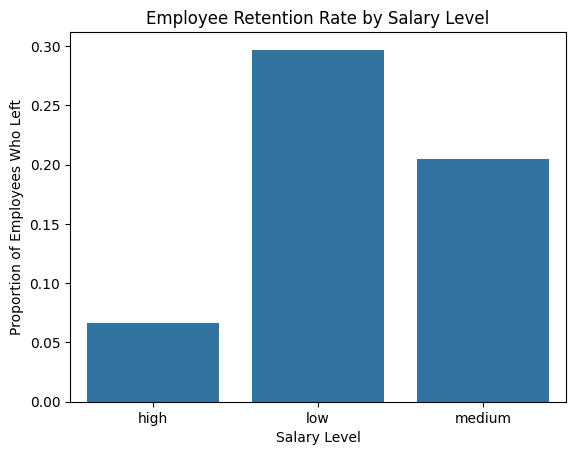

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

retention_by_salary = df.groupby('salary')['left'].value_counts(normalize=True).unstack()
retention_by_salary = retention_by_salary.rename(columns={0: 'Stayed', 1: 'Left'})

plt.figure()
sns.barplot(x=retention_by_salary.index, y=retention_by_salary['Left'])
plt.xlabel('Salary Level')
plt.ylabel('Proportion of Employees Who Left')
plt.title('Employee Retention Rate by Salary Level')
plt.show()

## Correlation Department vs. Retention

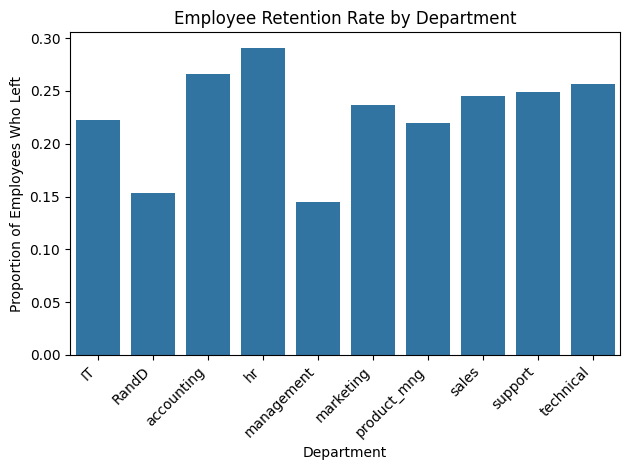

In [11]:
retention_by_department = df.groupby('Department')['left'].value_counts(normalize=True).unstack()
retention_by_department = retention_by_department.rename(columns={0: 'Stayed', 1: 'Left'})

plt.figure()
sns.barplot(x=retention_by_department.index, y=retention_by_department['Left'])
plt.xlabel('Department')
plt.ylabel('Proportion of Employees Who Left')
plt.title('Employee Retention Rate by Department')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Data Preprocessing


In [13]:
from sklearn.model_selection import train_test_split
import pandas as pd

In [14]:
X = df[['satisfaction_level', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'promotion_last_5years', 'Department', 'salary']]
y = df['left']

In [15]:
X = pd.get_dummies(X, columns=['Department', 'salary'], drop_first=True)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
X_train.head()

,satisfaction_level,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical,salary_low,salary_medium
9838,1.00,188,4,0,0,False,False,False,False,False,True,False,False,False,True,False
7689,0.16,196,5,0,0,False,False,False,False,False,False,False,False,True,False,False
6557,0.80,175,2,0,0,True,False,False,False,False,False,False,False,False,False,True
6872,0.66,112,6,0,0,False,True,False,False,False,False,False,False,False,False,True
820,0.11,284,4,0,0,False,False,False,False,False,False,False,False,True,True,False


In [18]:
y_train.head()

9838    0
7689    0
6557    0
6872    0
820     1
Name: left, dtype: int64

Logistic Regression


In [25]:
from sklearn.preprocessing import StandardScaler
scalerer = StandardScaler()
X_train = scalerer.fit_transform(X_train)
X_test = scalerer.transform(X_test)
X_train, X_test

(array([[ 1.55539086, -0.2608872 ,  0.34061666, ..., -0.47026373,
          1.02660601, -0.87053873],
        [-1.81839394, -0.10065248,  1.02407141, ...,  2.12646636,
         -0.97408353, -0.87053873],
        [ 0.75210876, -0.52126862, -1.02629282, ..., -0.47026373,
         -0.97408353,  1.14871397],
        ...,
        [ 0.18981129,  0.96090253, -1.02629282, ..., -0.47026373,
         -0.97408353,  1.14871397],
        [ 0.71194466,  0.33999299,  1.02407141, ..., -0.47026373,
          1.02660601, -0.87053873],
        [ 1.47506265,  0.36002233,  0.34061666, ..., -0.47026373,
          1.02660601, -0.87053873]]),
 array([[ 0.14964719,  0.50022771, -1.02629282, ..., -0.47026373,
         -0.97408353,  1.14871397],
        [ 1.0734216 , -0.70153267, -1.02629282, ..., -0.47026373,
          1.02660601, -0.87053873],
        [ 0.31030361,  0.25987563, -1.02629282, ..., -0.47026373,
          1.02660601, -0.87053873],
        ...,
        [ 0.67178055, -0.1607405 , -0.34283808, ..., -

In [26]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

In [27]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 1])

In [28]:
pd.DataFrame({'y_test': y_test, 'y_pred': y_pred})

,y_test,y_pred
6723,0,0
6473,0,0
4679,0,0
862,1,0
7286,0,0
...,...,...
3297,0,0
14113,0,0
5514,0,0
9939,0,0


In [29]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
accuracy


0.7633333333333333

### Results:

 Findings from Exploratory Data Analysis (EDA):\
 Employee departure is highly connected with lower levels of satisfaction\
 Longer tenured employees also have a higher turnover rate.\
 There is an imbalance in the dataset, with more employees remaining than departing.\
 'Sales' is the biggest department, and 'low' is the typical pay grade.\
\
 The results of the visualization show that salary level has a major effect on retention: employees with low wages are more likely to leave than those with medium or high pay.\
 Department has an impact on retention as well; some departments have a somewhat higher or lower percentage of departing personnel than others.\
\
 Assessment of the Logistic Regression Model:  On the test set, the Logistic Regression model's accuracy is 0.761.\
 Approximately 76.1% of the employees in the test set had their employee retention status accurately predicted by the model, according to this accuracy score.